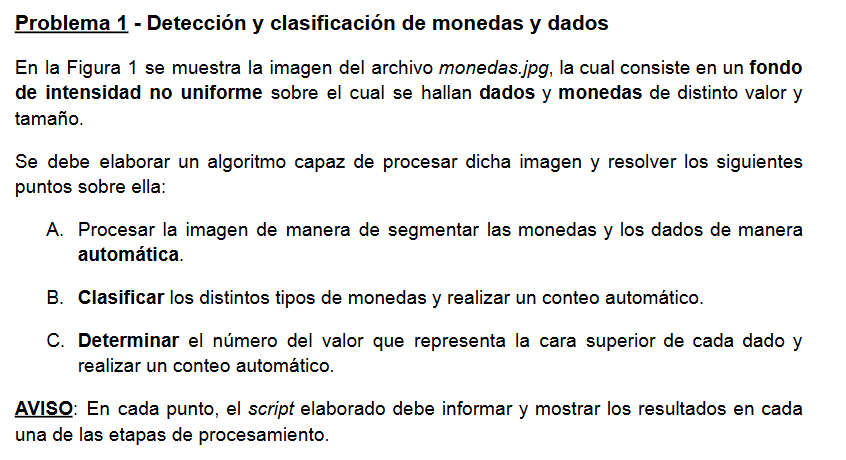

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

# PARTE A

tecnica top-hat (PI_U6_Morfologico_pt_grises.py)

In [182]:
img_color = cv2.imread('img/monedas.jpg')
gray = cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY)

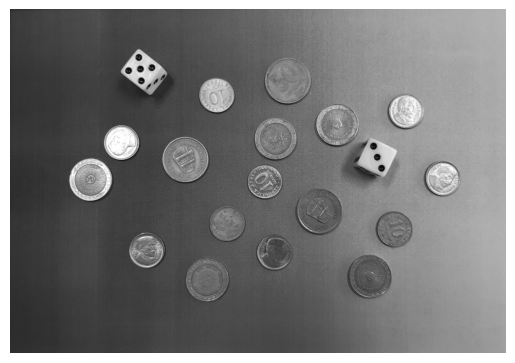

In [3]:
gray_blur = cv2.GaussianBlur(gray, (3, 3), 1)

plt.imshow(gray_blur, cmap='gray')
plt.axis('off')
plt.show()

usar top-hat para aplanar el fondo (PI_U6_Morfologico_pt_grises.py)

getStructuringElement:

cv2.MORPH_ELLIPSE: Le dice a OpenCV que la forma sea una elipse (un círculo). Elegimos esto porque tus objetos (las monedas) son redondos.

(35, 35): Este es el tamaño de la elipse (35x35 píxeles). Este tamaño es la clave: debe ser más grande que los objetos que quieres encontrar.

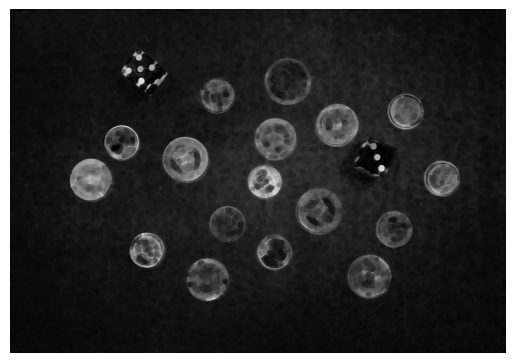

In [81]:
# Operaciones Top-Hat y Black-Hat
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (35, 35))

# Top-Hat 
# Lo usamos para encontrar todos los objetos brillantes en la imagen que son más pequeños que el kernel.
tophat = cv2.morphologyEx(gray_blur, cv2.MORPH_TOPHAT, kernel)

# Black-Hat
# Lo usamos para encontrar todos los objetos oscuros en la imagen que son más pequeños que el kernel.
blackhat = cv2.morphologyEx(gray_blur, cv2.MORPH_BLACKHAT, kernel)

# combinar mascaras
# Obtiene una única imagen donde el fondo no uniforme ha sido completamente eliminado (es negro) y todos los objetos (brillantes y oscuros) están resaltados.
mask = cv2.add(tophat, blackhat)

plt.imshow(mask, cmap='gray')
plt.axis('off')
plt.show()

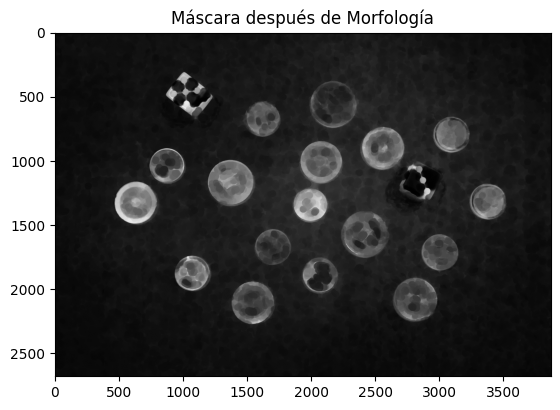

In [196]:
# Definir un kernel (el pincel con el que modificamos la imagen)
kernel = np.ones((3, 3), np.uint8)

# 1. Primero eliminamos el ruido del fondo (Apertura)
mask_clean = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=1)

# 2. Luego cerramos los huecos dentro de las monedas (Cierre)
# Aumentamos las iteraciones para cerrar huecos más grandes
mask_closed = cv2.morphologyEx(mask_clean, cv2.MORPH_CLOSE, kernel, iterations=4)

# Visualizar resultado intermedio
plt.imshow(mask_closed, cmap='gray')
plt.title("Máscara después de Morfología")
plt.show()

# --- AHORA BUSCAS CONTORNOS EN mask_closed ---
contours, _ = cv2.findContours(mask_closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

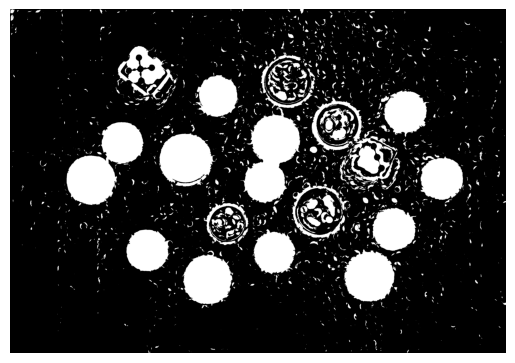

In [ ]:
# Encontrar contornos externos
contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Crear una máscara negra vacía
mask_final = np.zeros_like(mask)

# Dibujar todos los contornos rellenos (thickness=-1) con color blanco (255)
cv2.drawContours(mask_final, contours, -1, 255, thickness=cv2.FILLED)

plt.imshow(mask_final, cmap='gray')
plt.axis('off')
plt.show()

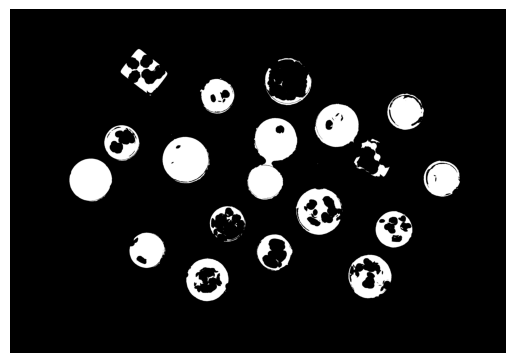

In [174]:
#umbralado
ret, mask_thresh = cv2.threshold(mask, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

plt.imshow(mask_thresh, cmap='gray')
plt.axis('off')
plt.show()

In [ ]:
# componenes conectadas
(num_labels, labels, stats, centroids) = cv2.connectedComponentsWithStats(
    mask_final, 8, cv2.CV_32S
) 

output_image = img_color.copy()
objetos_reales = 0

for i in range(1, num_labels): # Empezamos en 1 para saltar el fondo
    area = stats[i, cv2.CC_STAT_AREA]
    
    # filtramos objetos muy pequeños (ruido)
    if area < 8000: 
        continue
    
    objetos_reales += 1
    x = stats[i, cv2.CC_STAT_LEFT]
    y = stats[i, cv2.CC_STAT_TOP]
    w = stats[i, cv2.CC_STAT_WIDTH]
    h = stats[i, cv2.CC_STAT_HEIGHT]
    
    cv2.rectangle(output_image, (x, y), (x + w, y + h), (0, 255, 0), 2)
    (cX, cY) = centroids[i] 
    cv2.putText(output_image, str(i), (int(cX) - 10, int(cY)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 2)

print(f"Se encontraron {objetos_reales} objetos.")

Se encontraron 2 objetos.


(np.float64(-0.5), np.float64(3870.5), np.float64(2680.5), np.float64(-0.5))

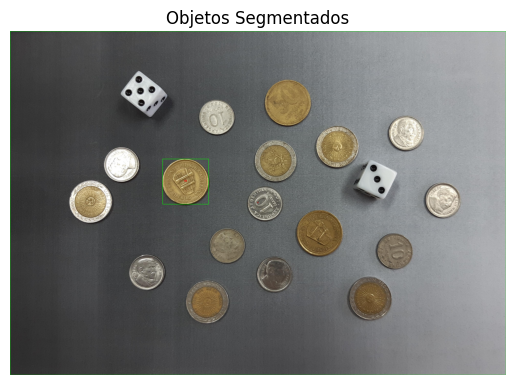

In [110]:
plt.imshow(cv2.cvtColor(output_image, cv2.COLOR_BGR2RGB))
plt.title('Objetos Segmentados')
plt.axis('off')

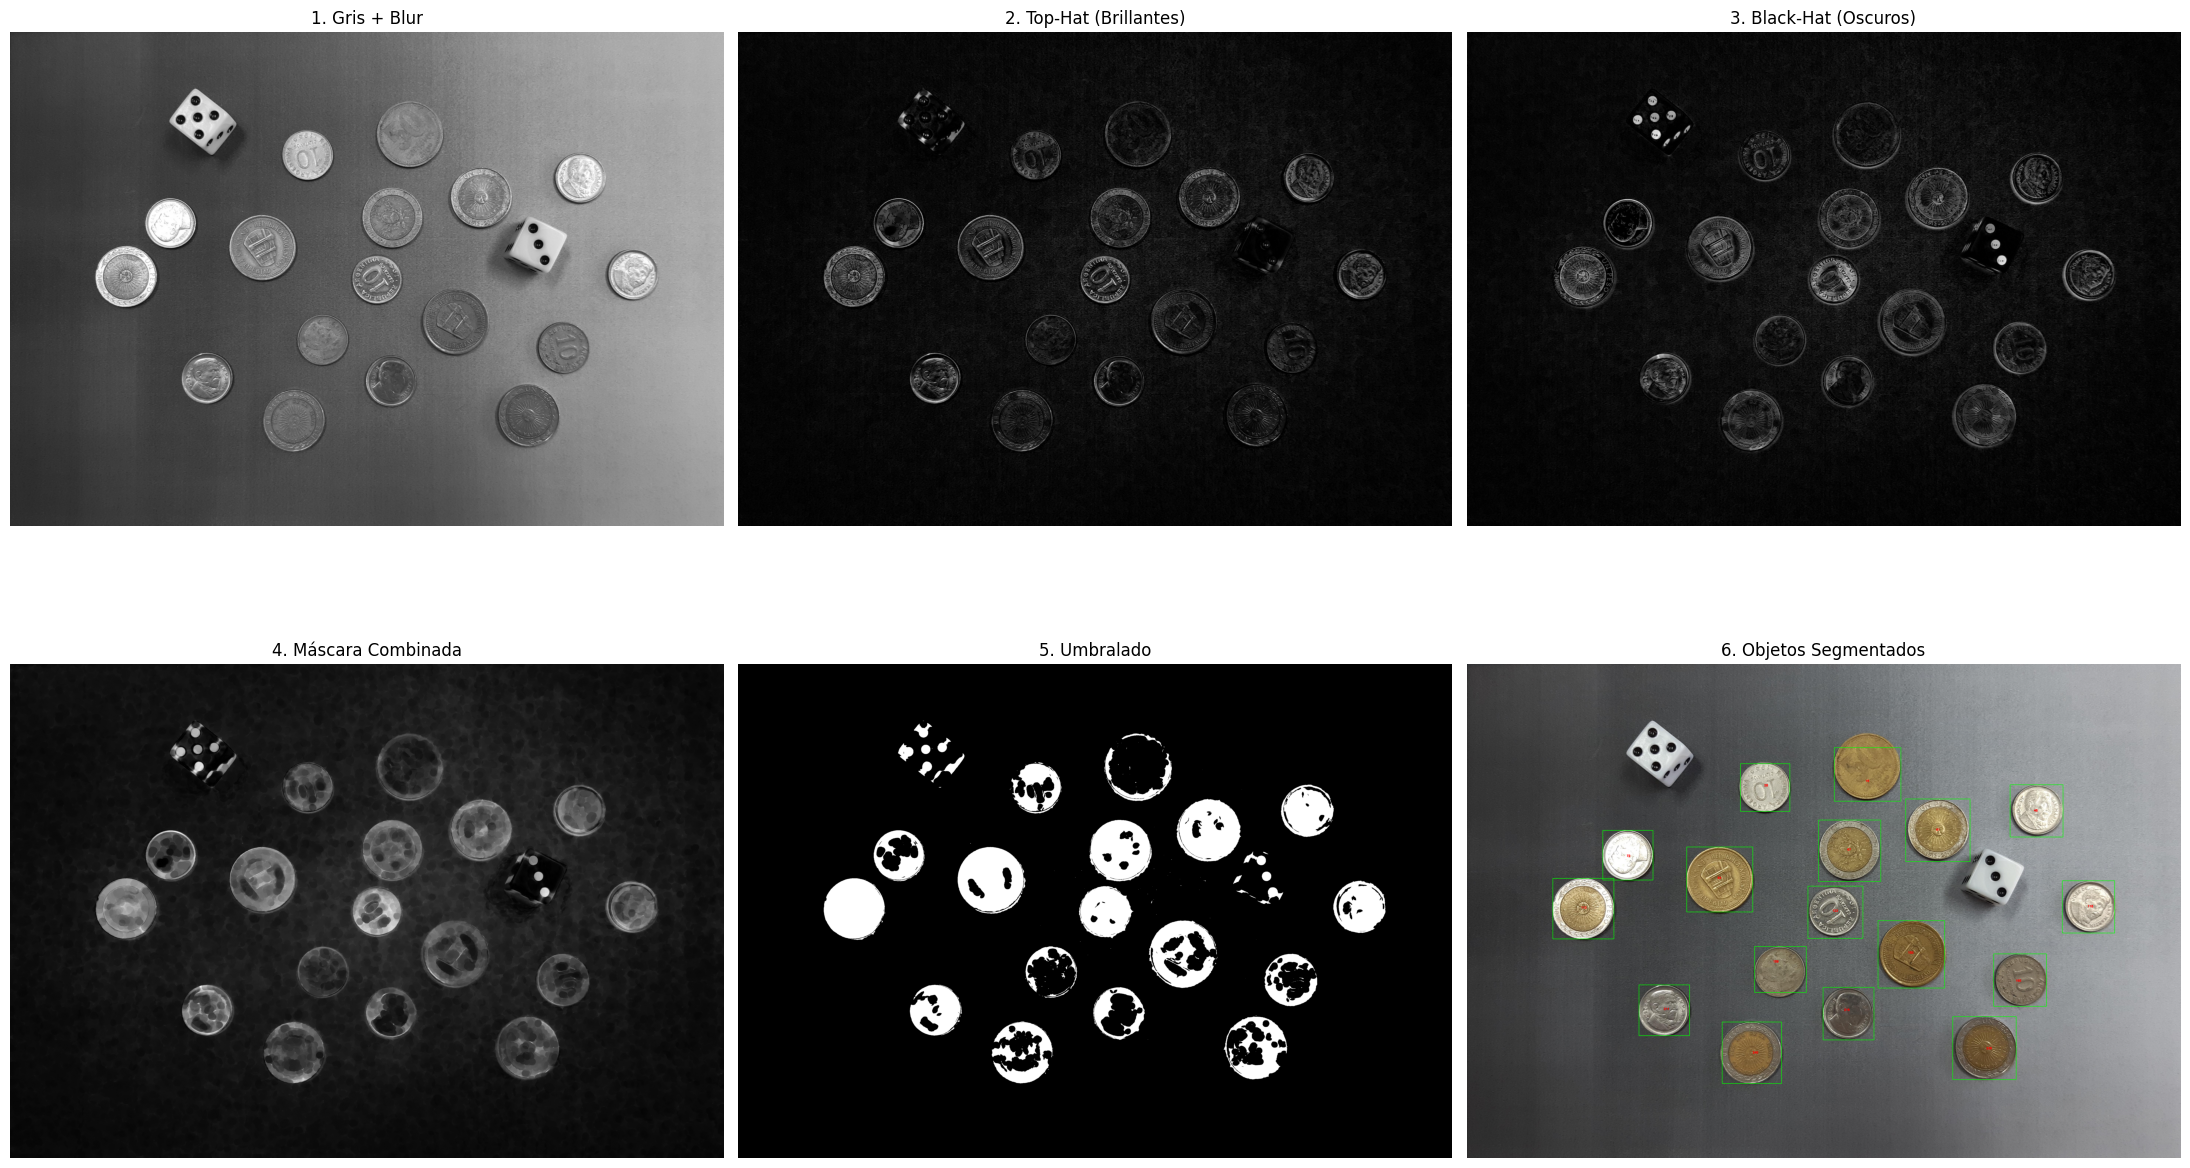

In [9]:
plt.figure(figsize=(22, 14))

plt.subplot(2, 3, 1)
plt.imshow(gray_blur, cmap='gray')
plt.title('1. Gris + Blur')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(tophat, cmap='gray')
plt.title('2. Top-Hat (Brillantes)')
plt.axis('off')

plt.subplot(2, 3, 3)
plt.imshow(blackhat, cmap='gray')
plt.title('3. Black-Hat (Oscuros)')
plt.axis('off')

plt.subplot(2, 3, 4)
plt.imshow(mask, cmap='gray')
plt.title('4. Máscara Combinada')
plt.axis('off')

plt.subplot(2, 3, 5)
plt.imshow(mask_thresh, cmap='gray')
plt.title('5. Umbralado')
plt.axis('off')

plt.subplot(2, 3, 6)
plt.imshow(cv2.cvtColor(output_image, cv2.COLOR_BGR2RGB))
plt.title('6. Objetos Segmentados')
plt.axis('off')

plt.tight_layout()
plt.show()